# **Modeling Drug-Cell Growth Interaction: A Comparison Between Continuous and Stochastic Approaches**

Francesca Mori

### **1. Introduction**

This project explores the interaction between pharmacology and cellular population dynamics.

Specifically, we investigate how the temporal degradation of a drug influences the proliferation of a cellular population. In the presented model, for simplicity, it was assumed that the drug was the only cause of death. In a more realistic scenario, a baseline death rate could be introduced. This would increase the stochastic variability of the system, making the risk of extinction even more significant.

The core of this study is to compare two fundamental modeling frameworks:
* A Deterministic (Continuous) Approach: using Ordinary Differential Equations (ODEs) to describe the "average" behavior of large populations.

* A Stochastic Approach: utilizing the Bienaymé-Galton-Watson branching process to capture the impact of randomness, which is particularly relevant when dealing with small initial cell numbers.

In [1]:
# here we import the libraries we need
import numpy as np
import matplotlib.pyplot as plt

### **2. Drug Dynamics**



In biological systems, the concentration of a drug is rarely constant. We consider a drug $A$ that undergoes irreversible degradation (metabolization or decay) according to a first-order kinetic law:

$$\dot A=-kA$$

The analytical solution for the drug concentration over time is:

$$A(t)=A_0e^{-kt}$$

Where $A_0$ represents the initial dosage and $k$ is the degradation constant, which determines the drug's half-life:
$$t_{1/2} = \ln(2)/k$$

This decay will serve as the time-dependent input for our growth models.

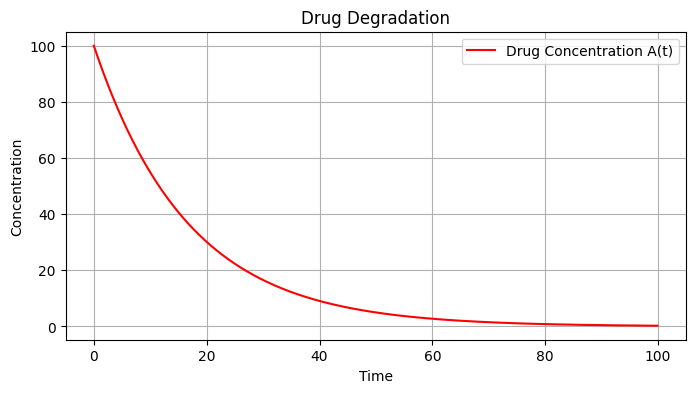

In [2]:
# First, we set the parameters:
A0 = 100      # Initial drug concentration
k = 0.06      # Degradation rate
dt = 0.1      # Time step
t_max = 100   # Maximum time
t = np.arange(0, t_max, dt)

# Analytical solution: A(t) = A0 * exp(-kt)
A = A0 * np.exp(-k * t)

# Now we can plot the drug decay
plt.figure(figsize=(8, 4))
plt.plot(t, A, label='Drug Concentration A(t)', color='red')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Drug Degradation')
plt.grid(True)
plt.legend()
plt.show()

### **3. Continuous Model**

In the continuous framework, we treat the population size $n(t)$ as a differentiable function.

**3.1 Time-Dependent Growth Rate**

The impact of the drug is modeled by assuming that the net growth rate $\gamma_{net}$ is inhibited linearly by the drug concentration:

$$γ_{net}(t)=γ_0 - αA(t)=γ_0 - αA_0e^{-kt}$$

Where:

* $γ_0$: basal growth rate in the absence of the drug,
* $α$: toxicity coefficient (drug efficacy).

In [3]:
# Here we define the parameters:
gamma0 = 0.2    # Basal growth rate
alpha = 0.01    # Toxicity (effect of drug on growth)
n0 = 1000        # Initial population size

**3.2 Malthus Equation: Unbounded Growth**

The simplest growth model we could start with is Malthus equation, in which we substitute $\gamma_{net}(t)$ and obtain:

$$\dot n =γ_{net}(t)n=(γ_0 - αA_0e^{-kt})n$$

This model predicts that if $\alpha A(t) > \gamma_0$, the population will initially decline. However, as the drug concentration decays, the growth rate eventually becomes positive again, leading to an unbounded exponential explosion.

We can solve the equation numerically using the Euler’s forward method, which uses a first order approximation of the derivative: $n_{i+1} = n_i + \dot{n} \Delta t = n_i + f(t,n_i) \Delta t$.

In [4]:
# Initialization of the array for results
n_malthus = np.zeros(len(t))
n_malthus[0] = n0

# Numerical Integration: Euler Method
for i in range(len(t)-1):

    # Net growth rate based on drug concentration at time i
    gamma_net = gamma0 - alpha * A[i]

    # Modified Malthus: dn = gamma_net * n * dt
    n_malthus[i+1] = n_malthus[i] + (gamma_net * n_malthus[i]) * dt

    # Check to avoid negative populations due to drug toxicity
    if n_malthus[i+1] < 0: n_malthus[i+1] = 0

**3.3 Logistic model: bounded growth**

To account for limited resources or space, we implement the logistic equation, substituting $\gamma_{net}(t)$:

$$\dot n =γ_{net}(t)n(1-\frac{n}{\theta})=(γ_0 - αA_0e^{-kt})n(1-\frac{n}{\theta})$$

Where $\theta$ represents the carrying capacity.

We can notice that after the initial inhibitory phase of the drug, the population grows until it saturates at the steady state $n = \theta$.

We can solve the equation numercally using Euler's method.

In [5]:
# We define the Carrying capacity parameter:
theta = 1100

# Initialization of the array for results
n_logistic = np.zeros(len(t))
n_logistic[0] = n0

# Numerical Integration (Euler Method)
for i in range(len(t)-1):

    # Net growth rate based on drug concentration at time i
    gamma_net = gamma0 - alpha * A[i]

    # Modified Logistic: dn = gamma_net * n * (1 - n/theta) * dt
    n_logistic[i+1] = n_logistic[i] + (gamma_net * n_logistic[i] *
     (1 - n_logistic[i]/theta)) * dt

    # Check to avoid negative populations due to drug toxicity
    if n_logistic[i+1] < 0: n_logistic[i+1] = 0

**3.4 Comparison**

Now we can graphically compare the two continuous models:

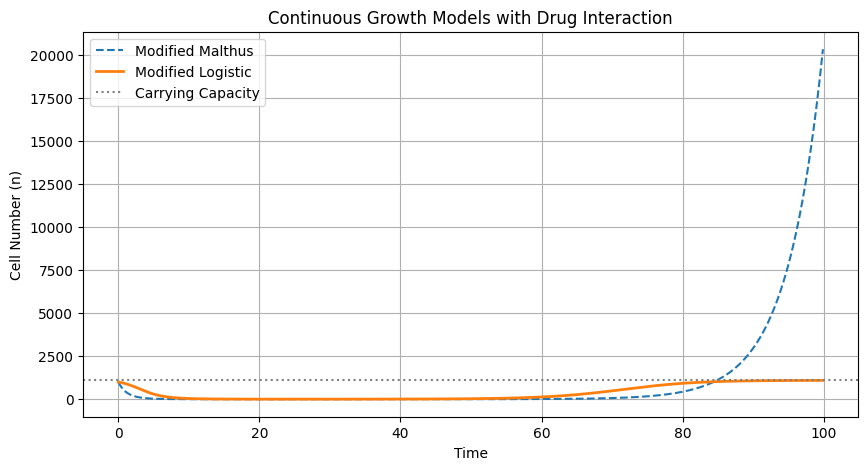

In [6]:
# Plotting Comparison
plt.figure(figsize=(10, 5))

# Modified Malthus
plt.plot(t, n_malthus, label='Modified Malthus', linestyle='--')

# Modified Logistic
plt.plot(t, n_logistic, label='Modified Logistic', linewidth=2)

# Carrying Capacity
plt.axhline(y=theta, color='gray', linestyle=':', label='Carrying Capacity')

plt.xlabel('Time')
plt.ylabel('Cell Number (n)')
plt.title('Continuous Growth Models with Drug Interaction')
plt.legend()
plt.grid(True)
plt.show()

In the Malthus model the population initially decreases, and then, as the drug decays, the population resumes an exponential and unbounded growth. This approach is useful for short-term analysis to see the immediate effect of the drug, but it is biologically unrealistic for long time scales.

On the other hand, the Logistic model is more realistic and more representative of in vitro or in vivo scenarios. Even after the drug's inhibitory phase, the population does not grow indefinitely but converges toward the steady state $n = \theta$.

However, for semplicity reasons, we will use Malthus model for the final comparison with the branching model.

### **4. Stochastic model**

Continuous models assume a "mean-field" behavior, which can be misleading when the number of individuals is low.

To capture the effects of randomness and stochastic fluctuations, we implement a Bienaymé-Galton-Watson branching process.

At each discrete time step $\Delta t$, each cell can:
1. Die with probability: $p_{death} = \alpha A(t) \Delta t$  (the drug is the only cause of death)
2. Divide with probability: $p_{div} = \gamma_0 \Delta t$
3. Survive without dividing with probability: $1 - (p_{death} + p_{div})$

In this framework, the drug's efficacy is modeled as a time-dependent increase in the probability of death. When the drug concentration $A(t)$ is sufficiently high, $p_{death}$ exceeds $p_{div}$, leading to a transient decay of the population.

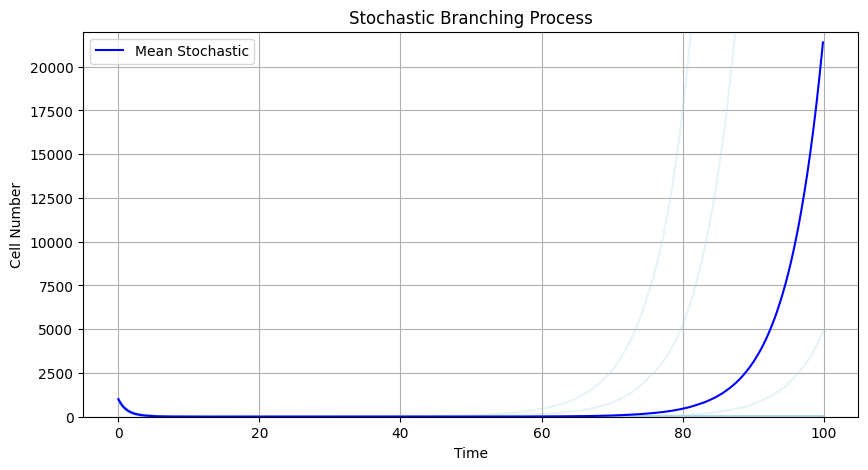

In [7]:
def simulate_branching(n0, t, A, gamma0, alpha):
    n = np.zeros(len(t))
    n[0] = n0
    for i in range(len(t)-1):
        current_n = int(n[i])
        if current_n <= 0:
            break # Extinction

        # Calculate time-dependent probabilities
        # In a small dt: Prob(division) approx gamma0*dt,
        #                Prob(death) approx alpha*A*dt

        p_div = gamma0 * dt
        p_death = alpha * A[i] * dt  # The drug increases death probability

        # New cells in this step
        change = 0
        for _ in range(current_n):
            r = np.random.random()
            if r < p_div:
                change += 1  # Division
            elif r < (p_div + p_death):
                change -= 1  # Death

        n[i+1] = current_n + change
    return n

# Reproducibility
np.random.seed(1)

# Run multiple simulations
num_sims = 50
plt.figure(figsize=(10, 5))

all_sims = []
for _ in range(num_sims):
    sim = simulate_branching(n0, t, A, gamma0, alpha)
    all_sims.append(sim)
    plt.plot(t, sim, color='lightblue', alpha=0.3)

# Plot of the mean of stochastic simulations and
# of the continuous Malthus for comparison
mean_sim = np.mean(all_sims, axis=0)
plt.plot(t, mean_sim, color='blue', label='Mean Stochastic')
plt.ylim(0, 22000)
plt.title('Stochastic Branching Process')
plt.xlabel('Time')
plt.ylabel('Cell Number')
plt.legend()
plt.grid(True)
plt.show()

### **5. Comparison and discussion**

Finally, we compare the average of multiple stochastic realizations with the deterministic trajectory of Malthus model.

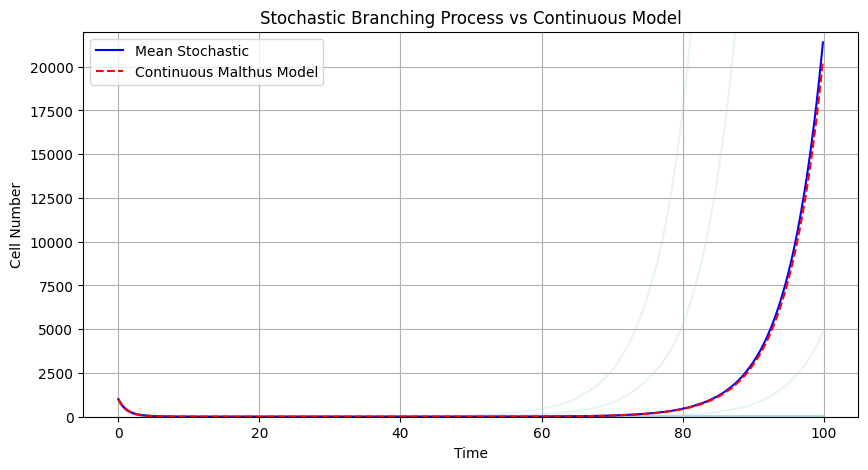

In [8]:
# Reproducibility
np.random.seed(1)

# Run multiple simulations
num_sims = 50
plt.figure(figsize=(10, 5))

all_sims = []
for _ in range(num_sims):
    sim = simulate_branching(n0, t, A, gamma0, alpha)
    all_sims.append(sim)
    plt.plot(t, sim, color='lightblue', alpha=0.3)

# Plot the mean of stochastic simulations and
# the continuous Malthus for comparison
mean_sim = np.mean(all_sims, axis=0)
plt.plot(t, mean_sim, color='blue', label='Mean Stochastic')
plt.plot(t, n_malthus, color='red', linestyle='--',
         label='Continuous Malthus Model')

plt.title('Stochastic Branching Process vs Continuous Model')
plt.ylim(0, 22000)
plt.xlabel('Time')
plt.ylabel('Cell Number')
plt.legend()
plt.grid(True)
plt.show()

A critical observation in this project is the discrepancy between the continuous and stochastic models at low $n_0$.

In a deterministic model, if $n_0 > 0$ and the drug decays, the population is destined to recover regardless of the initial pressure. In the stochastic version, if the drug's initial impact is severe, the population might hit $n=0$ due to a run of "bad luck" (random deaths). Once the population reaches zero, it is extinct, regardless of how much the drug decays afterward.

By running Monte Carlo simulations, we observe that if the initial drug dose is sufficiently potent, there is a non-zero probability that the population reaches $n=0$ before the drug has time to decay. This divergence is particularly significant in populations with a low initial cell count, where random fluctuations can lead to total extinction even when the deterministic continuous model predicts long-term survival:

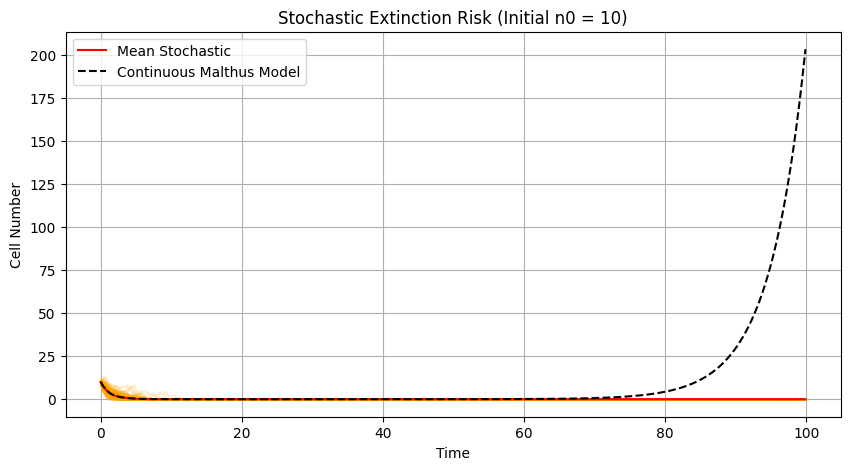

Percentage of simulations that went extinct: 100.0%


In [9]:
# Parameters for low initial population
n0_low = 10  # Very small initial population
num_sims_low = 100

# Recalculation of Continuous Malthus for n0_low
n_malthus_low = np.zeros(len(t))
n_malthus_low[0] = n0_low
for i in range(len(t)-1):
  gamma_net = gamma0 - alpha * A[i]
  n_malthus_low[i+1] = n_malthus_low[i] + (gamma_net * n_malthus_low[i]) * dt
  if n_malthus_low[i+1] < 0: n_malthus_low[i+1] = 0

# Reproducibility
np.random.seed(1)

# Running of simulations
plt.figure(figsize=(10, 5))
extinct_count = 0

all_sims_low = []
for _ in range(num_sims_low):
  sim = simulate_branching(n0_low, t, A, gamma0, alpha)
  all_sims_low.append(sim)
  if sim[-1] == 0:
    extinct_count += 1
  plt.plot(t, sim, color='orange', alpha=0.2)

mean_sim_low = np.mean(all_sims_low, axis=0)
plt.plot(t, mean_sim_low, color='red', label='Mean Stochastic')
plt.plot(t, n_malthus_low, color='black', linestyle='--',
         label='Continuous Malthus Model')

plt.title(f'Stochastic Extinction Risk (Initial n0 = {n0_low})')
plt.xlabel('Time')
plt.ylabel('Cell Number')
plt.legend()
plt.grid(True)
plt.show()

print(f"Percentage of simulations that went extinct: {extinct_count/num_sims_low
                                                      * 100}%")

This result highlights the bifurcation between the deterministic prediction (where the population always recovers) and the biological reality of small populations, where the initial 'bottleneck' created by the drug can lead to irreversible extinction.

### **6. Conclusion**

This project aimed to explore the interaction between pharmacology and population dynamics, assuming that the drug was the only cause of death for the cellular population.

The core of the study was to compare the Continuous and the Stochastic models.

By comparing the average of multiple Monte Carlo simulations with deterministic ODE trajectories, it becomes evident that while the "mean-field" approach provides an excellent approximation for the general trends of large populations, it fails to capture the critical variability and "threshold effects" inherent in biological systems.

For small colonies or populations under high stress, the stochastic model reveals essential extinction probabilities that deterministic calculus cannot predict, highlighting the vital role of hybrid modeling in clinical settings—where ensuring the total eradication of a pathogen or tumor requires accounting for these probabilistic risks.